# Cognifyz Intern Task 1: Predict Restaurant Ratings

## Objective

Build a machine learning model to predict restaurant ratings.

## Steps

1. Check missing values, null values, and duplicate values.
2. Encode categorical variables and split the data into training and testing sets.
3. Train and compare multiple regression algorithms:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor
   - XGBoost Regressor
   - CatBoost Regressor
4. Evaluate model performance using MAE, MSE, RMSE, and R² Score.
5. Interpret the results and identify the most influential features affecting restaurant ratings.

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sklearn
import xgboost


# 2. Load Dataset

In [57]:
df = pd.read_csv(r"D:\Project\cognifyz_projects\dataset\restaurant.csv")

# 3. Dataset Overview

In [58]:
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [60]:
df.shape

(9551, 21)

In [61]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [62]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

# 4. Data Cleaning
Missing Values, Encoding Categorical Variables and Splitting Data for Training and Testing set.

In [63]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [64]:
df.duplicated().sum()

0

# 5. Feature Selection

In [65]:
df_clean = df.drop(columns=['Restaurant ID','Restaurant Name','Address','Locality Verbose','Rating color','Rating text'])
df_clean.head(5)

,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,314
1,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,591
2,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,270
3,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,365
4,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,229


In [66]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          9551 non-null   int64  
 1   City                  9551 non-null   object 
 2   Locality              9551 non-null   object 
 3   Longitude             9551 non-null   float64
 4   Latitude              9551 non-null   float64
 5   Cuisines              9542 non-null   object 
 6   Average Cost for two  9551 non-null   int64  
 7   Currency              9551 non-null   object 
 8   Has Table booking     9551 non-null   object 
 9   Has Online delivery   9551 non-null   object 
 10  Is delivering now     9551 non-null   object 
 11  Switch to order menu  9551 non-null   object 
 12  Price range           9551 non-null   int64  
 13  Aggregate rating      9551 non-null   float64
 14  Votes                 9551 non-null   int64  
dtypes: float64(3), int64(

In [67]:
df_clean.columns

Index(['Country Code', 'City', 'Locality', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

In [68]:
df_clean.isnull().sum()

Country Code            0
City                    0
Locality                0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Votes                   0
dtype: int64

In [69]:
df_clean.duplicated().sum()

2

In [70]:
df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()

0

# 6. Exploratory Data Analysis (EDA)

In [71]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns
print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: Index(['Country Code', 'Longitude', 'Latitude', 'Average Cost for two',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')
Categorical Columns: Index(['City', 'Locality', 'Cuisines', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu'],
      dtype='object')


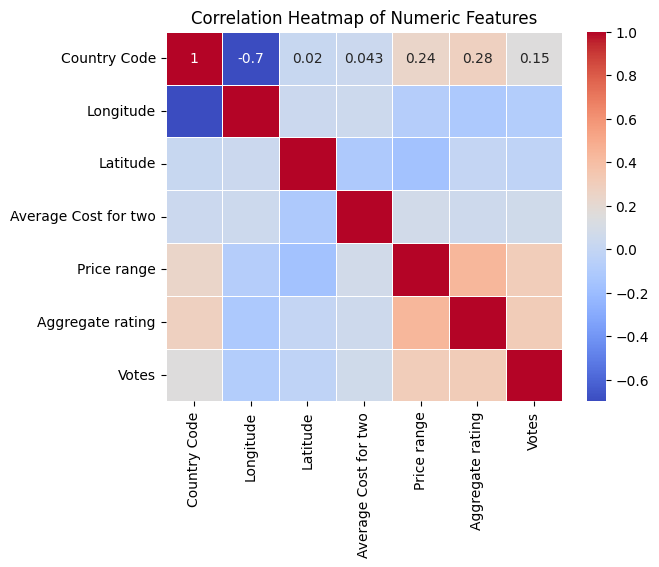

In [72]:
numeric_cols = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

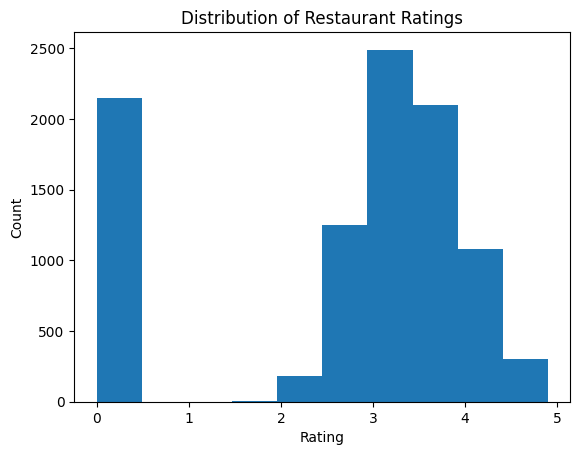

In [73]:
plt.hist(df_clean['Aggregate rating'])
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Restaurant Ratings')
plt.show()

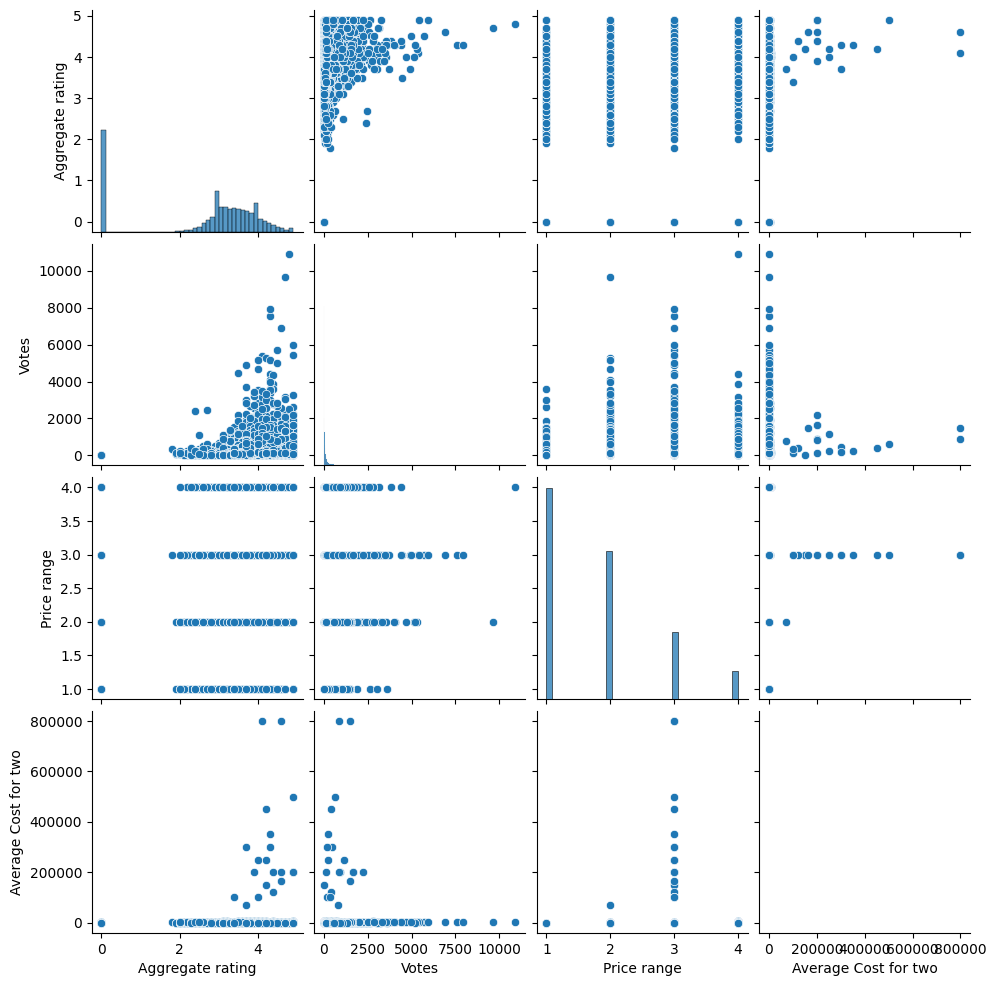

In [74]:
sns.pairplot(
    df_clean[
        ['Aggregate rating',
         'Votes',
         'Price range',
         'Average Cost for two']
    ]
)

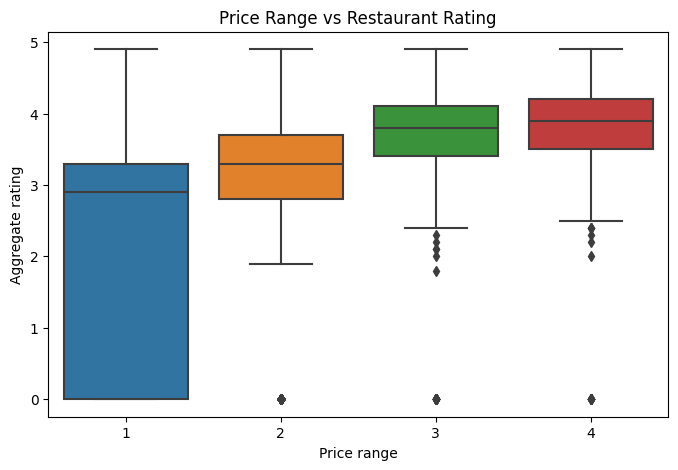

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Price range', y='Aggregate rating', data=df_clean)
plt.title('Price Range vs Restaurant Rating')
plt.show()

# 7. Feature Engineering

In [76]:
df_clean['Cuisines'].nunique()

for col in [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]:
    print(col, df_clean[col].unique())

Has Table booking ['Yes' 'No']
Has Online delivery ['No' 'Yes']
Is delivering now ['No' 'Yes']
Switch to order menu ['No']


In [77]:
df_clean['Cuisines'].nunique()

for col in [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]:
    print(col, df_clean[col].unique())

Has Table booking ['Yes' 'No']
Has Online delivery ['No' 'Yes']
Is delivering now ['No' 'Yes']
Switch to order menu ['No']


In [78]:
df_clean['Cuisines'].head(20)

0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
5                                Chinese
6                        Asian, European
7     Seafood, Filipino, Asian, European
8                European, Asian, Indian
9                               Filipino
10                     Filipino, Mexican
11         American, Ice Cream, Desserts
12                     Filipino, Mexican
13                              Filipino
14                                Korean
15     Cafe, American, Italian, Filipino
16                        Italian, Pizza
17                              Filipino
18                Cafe, Korean, Desserts
19       Cafe, Bakery, American, Italian
Name: Cuisines, dtype: object

In [79]:
print(df_clean['Cuisines'].nunique())

df_clean['Cuisines'].head(20)

1825


0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
5                                Chinese
6                        Asian, European
7     Seafood, Filipino, Asian, European
8                European, Asian, Indian
9                               Filipino
10                     Filipino, Mexican
11         American, Ice Cream, Desserts
12                     Filipino, Mexican
13                              Filipino
14                                Korean
15     Cafe, American, Italian, Filipino
16                        Italian, Pizza
17                              Filipino
18                Cafe, Korean, Desserts
19       Cafe, Bakery, American, Italian
Name: Cuisines, dtype: object

In [80]:
df_clean['Cuisines'].value_counts()

Cuisines
North Indian                                             936
North Indian, Chinese                                    511
Chinese                                                  354
Fast Food                                                354
North Indian, Mughlai                                    334
                                                        ... 
Bengali, Fast Food                                         1
North Indian, Rajasthani, Asian                            1
Chinese, Thai, Malaysian, Indonesian                       1
Bakery, Desserts, North Indian, Bengali, South Indian      1
Italian, World Cuisine                                     1
Name: count, Length: 1825, dtype: int64

In [81]:
df_clean['Primary Cuisine'] = (
    df_clean['Cuisines']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [82]:
yes_no_cols = [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]

for col in yes_no_cols:
    df_clean[col] = df_clean[col].map({
        'Yes': 1,
        'No': 0
    })

In [83]:
df_clean.drop(
    columns=['Cuisines'],
    inplace=True
)

In [84]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9549 entries, 0 to 9550
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          9549 non-null   int64  
 1   City                  9549 non-null   object 
 2   Locality              9549 non-null   object 
 3   Longitude             9549 non-null   float64
 4   Latitude              9549 non-null   float64
 5   Average Cost for two  9549 non-null   int64  
 6   Currency              9549 non-null   object 
 7   Has Table booking     9549 non-null   int64  
 8   Has Online delivery   9549 non-null   int64  
 9   Is delivering now     9549 non-null   int64  
 10  Switch to order menu  9549 non-null   int64  
 11  Price range           9549 non-null   int64  
 12  Aggregate rating      9549 non-null   float64
 13  Votes                 9549 non-null   int64  
 14  Primary Cuisine       9540 non-null   object 
dtypes: float64(3), int64(8), o

In [85]:
df_clean.columns

Index(['Country Code', 'City', 'Locality', 'Longitude', 'Latitude',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Votes', 'Primary Cuisine'],
      dtype='object')

In [86]:
df_clean['Primary Cuisine'].head()

0      French
1    Japanese
2     Seafood
3    Japanese
4    Japanese
Name: Primary Cuisine, dtype: object

# 8. Encoding

In [87]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_clean['Country Code'] = le.fit_transform(df_clean['Country Code'])
df_clean['City'] = le.fit_transform(df_clean['City'])
df_clean['Locality'] = le.fit_transform(df_clean['Locality'])
df_clean['Currency'] = le.fit_transform(df_clean['Currency'])
df_clean['Primary Cuisine'] = le.fit_transform(df_clean['Primary Cuisine'])

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9549 entries, 0 to 9550
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          9549 non-null   int64  
 1   City                  9549 non-null   int32  
 2   Locality              9549 non-null   int32  
 3   Longitude             9549 non-null   float64
 4   Latitude              9549 non-null   float64
 5   Average Cost for two  9549 non-null   int64  
 6   Currency              9549 non-null   int32  
 7   Has Table booking     9549 non-null   int64  
 8   Has Online delivery   9549 non-null   int64  
 9   Is delivering now     9549 non-null   int64  
 10  Switch to order menu  9549 non-null   int64  
 11  Price range           9549 non-null   int64  
 12  Aggregate rating      9549 non-null   float64
 13  Votes                 9549 non-null   int64  
 14  Primary Cuisine       9549 non-null   int32  
dtypes: float64(3), int32(4), i

# 9. Feature / Target Split

In [88]:
X = df_clean.drop('Aggregate rating', axis=1)
y = df_clean['Aggregate rating']

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
X_test

,Country Code,City,Locality,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Primary Cuisine
4730,0,88,540,77.136738,28.650349,500,4,0,0,0,0,2,20,27
1468,0,50,362,77.095432,28.460444,700,4,0,1,0,0,2,84,74
5217,0,88,651,77.120189,28.630814,350,4,0,0,0,0,1,6,100
4355,0,88,473,77.181008,28.549002,300,4,0,0,0,0,1,15,36
6533,0,88,832,77.176621,28.644294,1100,4,0,1,0,0,3,221,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6278,0,88,794,77.105851,28.691275,1000,4,1,0,0,0,3,21,79
8148,0,89,478,77.334855,28.576470,350,4,0,1,0,0,1,49,79
5849,0,88,706,77.251202,28.547266,400,4,0,0,0,0,1,1,79
9019,0,89,965,77.381743,28.520004,500,4,0,0,0,0,2,10,27


In [91]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7639, 14)
(1910, 14)
(7639,)
(1910,)


# 10. Model Training

In [92]:
!pip install catboost==1.2.5

# Model Used
-> LinearRegression
-> DecisionTreeRegressor
-> RandomForestRegressor
-> XGBRegressor 
-> CatBoostRegressor

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)
lr.predict(X_test)

dr = DecisionTreeRegressor(random_state=42)
dr.fit(X_train, y_train)
dr.predict(X_test)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf.predict(X_test)

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb.predict(X_test)

cb = CatBoostRegressor(verbose=0)
cb.fit(X_train, y_train)
cb.predict(X_test)

array([ 3.10624657e+00,  3.35706019e+00,  2.94483300e+00, ...,
       -1.92638661e-03,  2.98208048e+00,  4.24179965e+00])

In [94]:
lr_pred = lr.predict(X_test)
print(lr_pred)
dr_pred = dr.predict(X_test)
print(dr_pred)
rf_pred = rf.predict(X_test)
print(rf_pred)
xgb_pred = xgb.predict(X_test)
print(xgb_pred)
cb_pred = cb.predict(X_test)
print(cb_pred)

[2.53086047 3.3309015  1.7806596  ... 1.80885824 2.362972   3.32932072]
[2.5 3.7 2.8 ... 0.  3.  3.5]
[2.926 3.337 2.939 ... 0.    2.973 4.187]
[3.1090434  3.3123825  2.9613502  ... 0.02186406 2.9878924  4.184472  ]
[ 3.10624657e+00  3.35706019e+00  2.94483300e+00 ... -1.92638661e-03
  2.98208048e+00  4.24179965e+00]


In [95]:
print(lr_pred.shape)
print(dr_pred.shape)
print(rf_pred.shape)
print(xgb_pred.shape)
print(cb_pred.shape)

(1910,)
(1910,)
(1910,)
(1910,)
(1910,)


# 11. Model Evaluation
Mean Squared Error, R-Squard, MAE, RMSE

In [96]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd

In [97]:
def evaluate_model(model_name, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = mse ** 0.5

    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

In [98]:
lr_pred = lr.predict(X_test)

dr_pred = dr.predict(X_test)

rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

cb_pred = cb.predict(X_test)

In [99]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        "CatBoost",
        y_test,
        cb_pred
    )
)

In [100]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
4,CatBoost,0.1945,0.0842,0.2901,0.9636
2,Random Forest,0.1964,0.0894,0.2989,0.9614
3,XGBoost,0.2018,0.0921,0.3035,0.9602
1,Decision Tree,0.2699,0.1820,0.4266,0.9213
0,Linear Regression,1.0299,1.5363,1.2395,0.3359


In [101]:
mae = mean_absolute_error(y_test, lr_pred)

mse = mean_squared_error(y_test, lr_pred)

rmse = mean_squared_error(
    y_test,
    lr_pred
) ** 0.5

r2 = r2_score(y_test, lr_pred)
print("Linear Regression MAE:", mae)
print("Linear Regression MSE:", mse)
print("Linear Regression RMSE:", rmse)
print("Linear Regression R2 Score:", r2)


Linear Regression MAE: 1.0298848673364618
Linear Regression MSE: 1.5363405377553787
Linear Regression RMSE: 1.239492048282432
Linear Regression R2 Score: 0.33594897149442693


# 12. Feature Importance

In [102]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,Votes,91.962182
13,Primary Cuisine,1.378175
3,Longitude,1.216218
5,Average Cost for two,1.202776
4,Latitude,1.118538
2,Locality,0.783245
11,Price range,0.669524
0,Country Code,0.536347
1,City,0.438774
8,Has Online delivery,0.352530


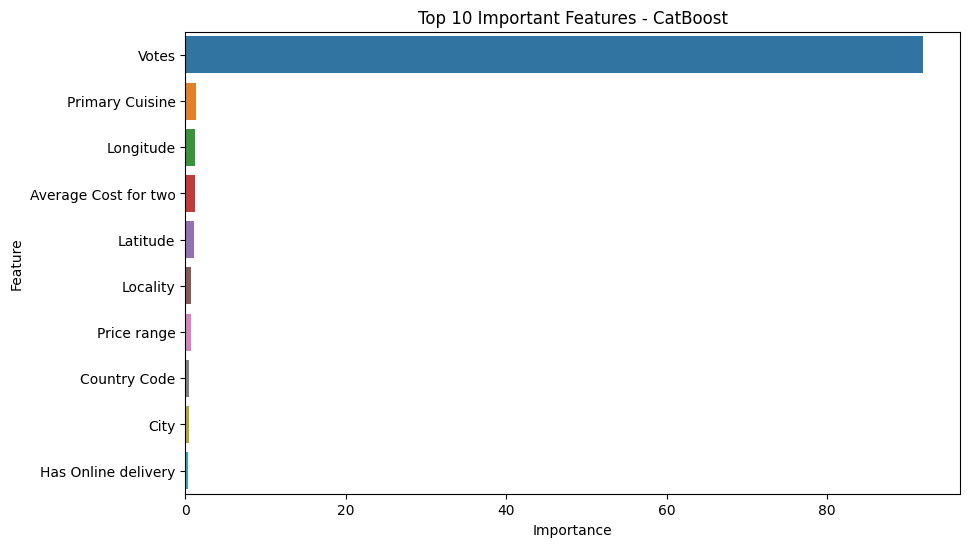

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features - CatBoost')
plt.show()

### Interpretation of Feature Importance

• Votes was identified as the most influential feature with an importance score of 91.96.

• Restaurants receiving a higher number of customer votes tend to have more predictable and generally higher ratings.

• Primary Cuisine, Average Cost for Two, Longitude, and Latitude also contribute to rating prediction but with much lower influence.

• Location-related features such as City, Locality, Latitude, and Longitude affect restaurant ratings moderately.

• Customer engagement (Votes) is the strongest factor influencing restaurant ratings in this dataset.

# 13. Model Persistence and Testing
Save the trained CatBoost model, reload it, and test predictions on unseen data.

In [104]:
import joblib

joblib.dump(
    cb,
    "models/catboost_model.pkl"
)

loaded_model = joblib.load(
    "models/catboost_model.pkl"
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print(
    "Predicted Rating:",
    prediction[0]
)

print(
    "Actual Rating:",
    y_test.iloc[0]
)

Predicted Rating: 3.1062465676837716
Actual Rating: 2.4


In [105]:
from sklearn.metrics import r2_score

loaded_pred = loaded_model.predict(X_test)

print(
    "Loaded Model R2:",
    r2_score(y_test, loaded_pred)
)

Loaded Model R2: 0.9636134243096921


# 14. Conclusion

This project focused on predicting restaurant ratings using machine learning techniques. The dataset was preprocessed by handling missing values, removing duplicates, performing feature engineering, encoding categorical variables, and splitting the data into training and testing sets.

Five regression models were trained and evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor
- CatBoost Regressor

Among all models, CatBoost Regressor achieved the best performance with an R² Score of 0.9636, MAE of 0.1945, and RMSE of 0.2901. Random Forest and XGBoost also produced excellent results, while Linear Regression showed comparatively lower performance, indicating that the relationship between restaurant features and ratings is non-linear.

Feature Importance Analysis revealed that Votes was the most influential feature affecting restaurant ratings, followed by Primary Cuisine, Longitude, Average Cost for Two, and Latitude. Feature importance helps identify which variables contribute most to model predictions and improves model interpretability.

The results demonstrate that ensemble-based machine learning models are highly effective for restaurant rating prediction. The trained CatBoost model was successfully saved, loaded, and tested, confirming its ability to generate predictions on unseen restaurant data.

Overall, the developed model can accurately predict restaurant ratings using restaurant characteristics, customer engagement metrics, cuisine information, pricing, and location-based features.